# 02 · Exploratory data analysis

How do solar-plant locations differ from non-solar land in each predictor? We compare class-conditional
distributions, check correlations (multicollinearity matters for interpreting importances), and look at how
the time-varying remote-sensing indices changed between the pre-construction baseline and today.

In [1]:
import sys, json, warnings
from pathlib import Path
warnings.filterwarnings('ignore')
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(ROOT))

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
from model import config
plt.rcParams.update({'figure.dpi': 110, 'savefig.dpi': 200, 'font.family': 'DejaVu Sans',
                     'axes.spines.top': False, 'axes.spines.right': False})

from model import viz
viz.apply_style()
from model.features import RAW_FEATURE_COLS, FEATURE_META, GLOBAL_FEATURE_META

## Tamil Nadu case study

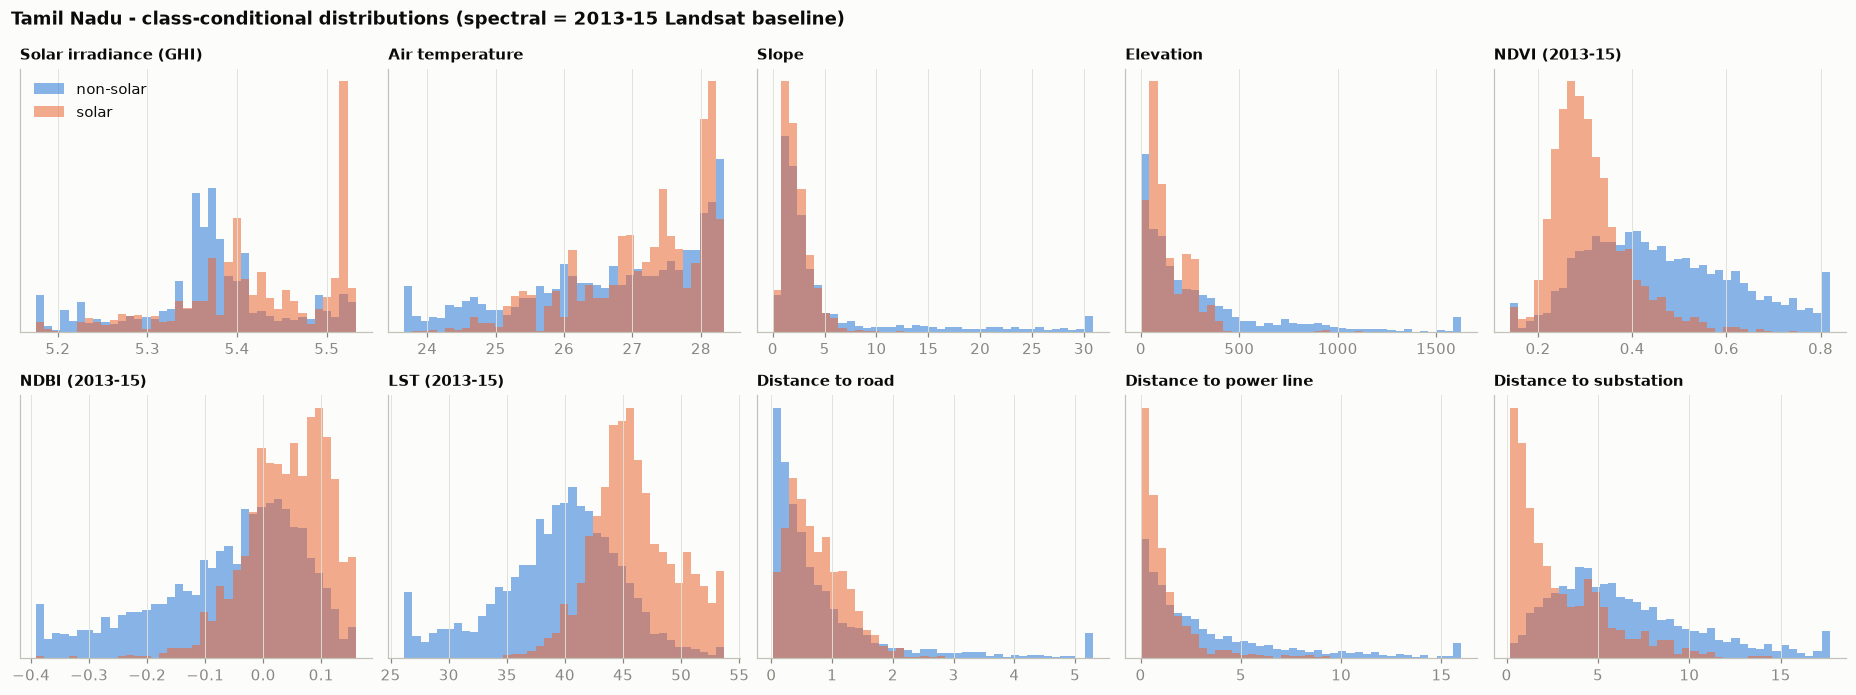

In [2]:
t = pd.read_csv(config.DATASET_CSV)
cols = ['ghi', 'temperature', 'slope', 'elevation', 'ndvi_pre', 'ndbi_pre', 'lst_pre',
        'dist_road_km', 'dist_powerline_km', 'dist_substation_km']
fig, axes = plt.subplots(2, 5, figsize=(17, 6.4))
for ax, c in zip(axes.ravel(), cols):
    lo, hi = t[c].quantile([0.01, 0.99])
    bins = np.linspace(lo, hi, 40)
    for lab, color, name in ((0, viz.SERIES[0], 'non-solar'), (1, viz.SERIES[1], 'solar')):
        ax.hist(t.loc[t.label == lab, c].clip(lo, hi), bins=bins, density=True, alpha=0.55, color=color, label=name)
    base = c.replace('_pre', '')
    ax.set_title(FEATURE_META.get(c, FEATURE_META.get(base, {'label': c}))['label'], fontsize=10)
    ax.set_yticks([])
axes[0, 0].legend()
plt.suptitle('Tamil Nadu - class-conditional distributions (spectral = 2013-15 Landsat baseline)', x=0.01, ha='left',
             fontweight='bold')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / 'eda_distributions_tamil_nadu.png', bbox_inches='tight'); plt.show()

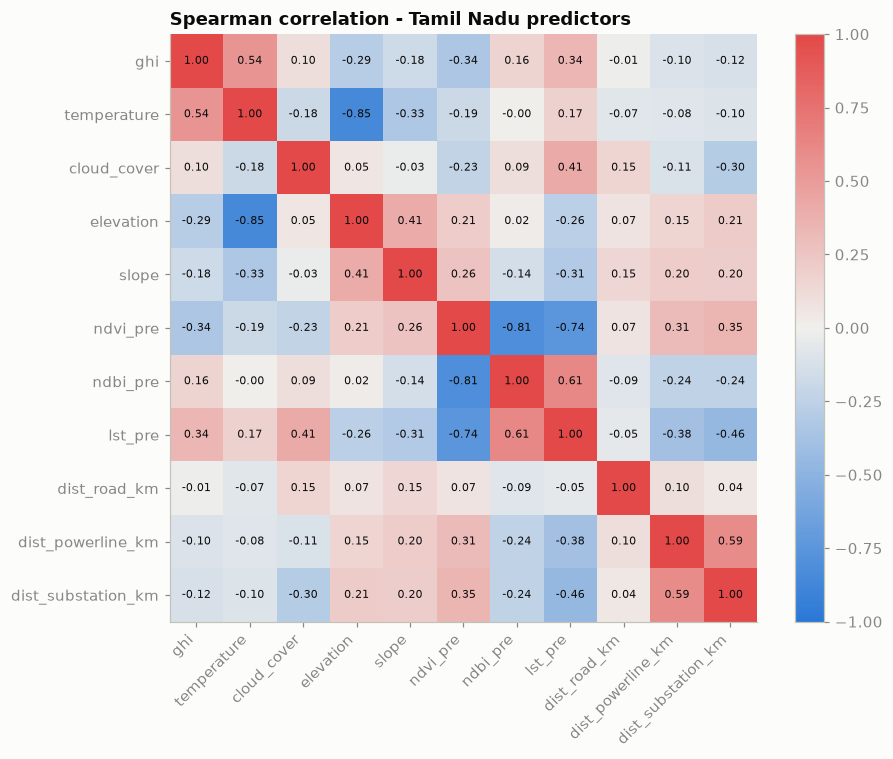

In [3]:
num = t[['ghi', 'temperature', 'cloud_cover', 'elevation', 'slope', 'ndvi_pre', 'ndbi_pre', 'lst_pre',
         'dist_road_km', 'dist_powerline_km', 'dist_substation_km']]
corr = num.corr(method='spearman')
fig, ax = plt.subplots(figsize=(8.5, 7)); ax.grid(False)
im = ax.imshow(corr, cmap=viz.SHAP_CMAP, vmin=-1, vmax=1)
ax.set_xticks(range(len(corr)), corr.columns, rotation=45, ha='right'); ax.set_yticks(range(len(corr)), corr.columns)
for i in range(len(corr)):
    for j in range(len(corr)):
        ax.text(j, i, f"{corr.iloc[i, j]:.2f}", ha='center', va='center', fontsize=7.5)
plt.colorbar(im, fraction=0.04); ax.set_title('Spearman correlation - Tamil Nadu predictors')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / 'eda_correlation_tamil_nadu.png', bbox_inches='tight'); plt.show()

### Leakage in 10 m Sentinel-2 / 30 m Landsat data
At solar sites the *current* NDBI and LST jump because the sensor sees panels and gravel, while negatives barely
change. This is why the Tamil Nadu model is trained on the 2013-15 values.

In [4]:
rows = []
for c in ['ndvi', 'ndbi', 'lst']:
    for lab in (0, 1):
        sub = t[t.label == lab]
        rows.append({'index': c.upper(), 'class': 'solar' if lab else 'non-solar',
                     '2013-15 median': sub[f'{c}_pre'].median(), 'now median': sub[c].median(),
                     'change': sub[c].median() - sub[f'{c}_pre'].median()})
pd.DataFrame(rows).round(3)

,index,class,2013-15 median,now median,change
0,NDVI,non-solar,0.443,0.450,0.008
1,NDVI,solar,0.295,0.199,-0.096
2,NDBI,non-solar,-0.030,-0.008,0.022
3,NDBI,solar,0.049,0.251,0.201
4,LST,non-solar,39.973,38.418,-1.555
5,LST,solar,45.621,44.545,-1.077


## Global dataset

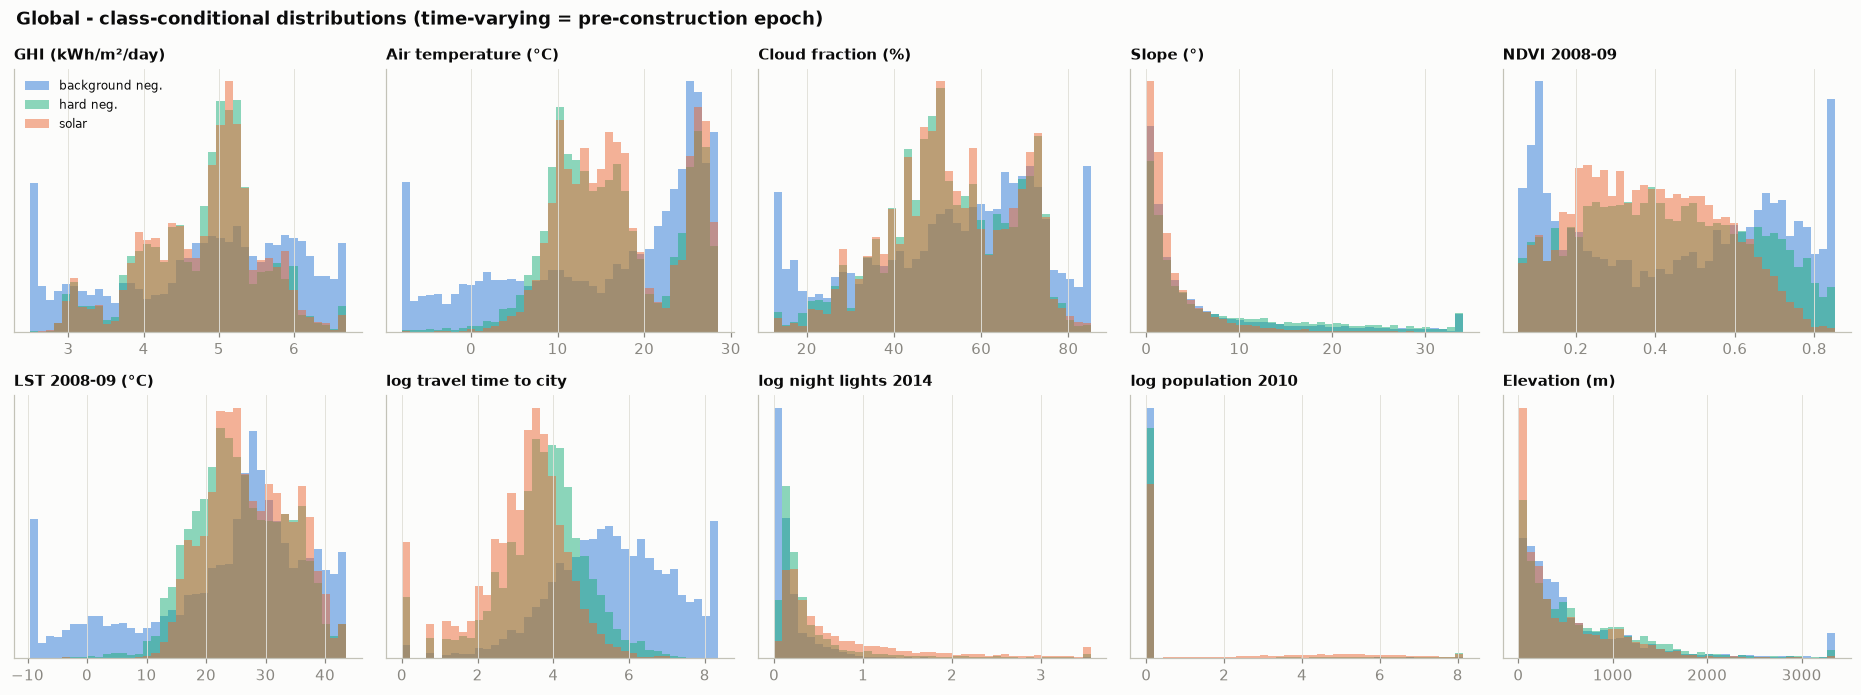

In [5]:
g = pd.read_csv(config.GLOBAL_DATASET_CSV)
g['log_access'] = np.log1p(g['accessibility'].clip(lower=0))
g['log_lights_pre'] = np.log1p(g['nightlights_pre'].clip(lower=0))
g['log_pop_pre'] = np.log1p(g['population_pre'].clip(lower=0))
cols = ['ghi', 'temperature', 'cloud_cover', 'slope', 'ndvi_pre', 'lst_pre', 'log_access', 'log_lights_pre', 'log_pop_pre', 'elevation']
titles = ['GHI (kWh/m²/day)', 'Air temperature (°C)', 'Cloud fraction (%)', 'Slope (°)', 'NDVI 2008-09', 'LST 2008-09 (°C)',
          'log travel time to city', 'log night lights 2014', 'log population 2010', 'Elevation (m)']
fig, axes = plt.subplots(2, 5, figsize=(17, 6.4))
for ax, c, ttl in zip(axes.ravel(), cols, titles):
    lo, hi = g[c].quantile([0.01, 0.99]); bins = np.linspace(lo, hi, 40)
    for (lab, nt), color, name in (((0, 'background'), viz.SERIES[0], 'background neg.'),
                                   ((0, 'hard'), viz.SERIES[2], 'hard neg.'), ((1, None), viz.SERIES[1], 'solar')):
        sub = g[(g.label == lab) & ((g.neg_type == nt) if nt else True)]
        ax.hist(sub[c].clip(lo, hi), bins=bins, density=True, alpha=0.5, color=color, label=name)
    ax.set_title(ttl, fontsize=10); ax.set_yticks([])
axes[0, 0].legend(fontsize=8)
plt.suptitle('Global - class-conditional distributions (time-varying = pre-construction epoch)', x=0.01, ha='left', fontweight='bold')
plt.tight_layout(); plt.savefig(config.FIGURES_DIR / 'eda_distributions_global.png', bbox_inches='tight'); plt.show()

**Reading the plots.** Background negatives are dominated by remote, cold, forested or desert land (long
travel times, no lights). Hard negatives look much more like plant sites - similar climate and access - which is
what forces the model to learn *local* differences (slope, vegetation, land surface temperature).

In [6]:
summary = g.groupby('label')[['ghi', 'temperature', 'cloud_cover', 'slope', 'accessibility', 'ndvi_pre',
                              'nightlights_pre', 'population_pre']].median().T
summary.columns = ['non-solar median', 'solar median']; summary.round(3)

,non-solar median,solar median
ghi,4.967,4.964
temperature,16.652,16.214
cloud_cover,54.101,52.502
slope,2.741,1.497
accessibility,86.000,28.000
ndvi_pre,0.441,0.377
nightlights_pre,0.178,0.522
population_pre,0.000,0.000
